In [2]:
# EDA 
# profile of data
# statical analysis
# graphical analysis

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
 
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("googleplaystore.csv")

In [5]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [6]:
df.sample(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2739,Checkout 51: Grocery coupons,SHOPPING,4.1,52896,Varies with device,"10,000,000+",Free,0,Everyone,Shopping,"June 18, 2018",Varies with device,Varies with device
161,ReadEra – free ebook reader,BOOKS_AND_REFERENCE,4.8,47303,21M,"1,000,000+",Free,0,Everyone,Books & Reference,"June 2, 2018",18.05.31+530,4.1 and up


In [7]:
df.shape

(10841, 13)

In [8]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

np.int64(483)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [14]:
df["Reviews"].unique()  # it is possoble that some string value is present n reveiews column then showing all the column as object 

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [15]:
"1".isnumeric()  # 1 is numeric inside str

True

In [16]:
df[~df.Reviews.str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [17]:
df_copy = df.copy()

In [18]:
df_copy = df_copy.reset_index()

In [19]:
df_copy[~df_copy.Reviews.str.isnumeric()]

,index,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9990,10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [20]:
df_copy = df_copy.drop(df_copy.index[9990])

In [21]:
df_copy.Reviews

0           159
1           967
2         87510
3        215644
4           967
          ...  
10353        38
10354         4
10355         3
10356       114
10357    398307
Name: Reviews, Length: 10357, dtype: object

In [22]:
df_copy["Reviews"] = df_copy["Reviews"].astype(int)

In [23]:
df_copy["Reviews"]

0           159
1           967
2         87510
3        215644
4           967
          ...  
10353        38
10354         4
10355         3
10356       114
10357    398307
Name: Reviews, Length: 10357, dtype: int64

In [24]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           10357 non-null  int64  
 1   App             10357 non-null  object 
 2   Category        10357 non-null  object 
 3   Rating          8892 non-null   float64
 4   Reviews         10357 non-null  int64  
 5   Size            10357 non-null  object 
 6   Installs        10357 non-null  object 
 7   Type            10356 non-null  object 
 8   Price           10357 non-null  object 
 9   Content Rating  10357 non-null  object 
 10  Genres          10357 non-null  object 
 11  Last Updated    10357 non-null  object 
 12  Current Ver     10349 non-null  object 
 13  Android Ver     10355 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 1.2+ MB


In [25]:
df_copy["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [26]:
item = "19M"
item[-1]

'M'

In [27]:
# 1 mb -->> 1024
def size_process(item):
    if str(item)[-1] == "M":
        res = float(str(item).replace("M",""))
        res = res * 1024
        return res 
    elif str(item)[-1] == "K":
        res = float(str(item).replace("K",""))
        return res
    else:
        return str(np.nan) 


In [28]:
df_copy["Size"] = df_copy["Size"].apply(size_process)
df_copy["Size"]

0        19456.0
1        14336.0
2         8908.8
3        25600.0
4         2867.2
          ...   
10353    54272.0
10354     3686.4
10355     9728.0
10356        nan
10357    19456.0
Name: Size, Length: 10357, dtype: object

In [29]:
df_copy.Size.unique()

array([19456.0, 14336.0, 8908.8, 25600.0, 2867.2, 5734.4, 29696.0,
       33792.0, 3174.4, 28672.0, 12288.0, 20480.0, 21504.0, 37888.0,
       2764.8, 5632.0, 17408.0, 39936.0, 31744.0, 4300.8, 7168.0, 23552.0,
       6144.0, 6246.4, 4710.4, 9420.8, 5324.8, 11264.0, 24576.0, 'nan',
       9625.6, 15360.0, 10240.0, 1228.8, 26624.0, 8192.0, 8089.6, 57344.0,
       58368.0, 35840.0, 55296.0, 3686.4, 5836.8, 8806.4, 2457.6, 27648.0,
       2560.0, 16384.0, 3481.6, 9113.6, 3993.6, 2969.6, 38912.0, 32768.0,
       5529.6, 18432.0, 1126.4, 2252.8, 4608.0, 10035.2, 53248.0, 9216.0,
       6860.8, 30720.0, 2662.4, 7270.4, 3788.8, 22528.0, 7577.6, 6553.6,
       3276.8, 8396.8, 10137.6, 5017.6, 9728.0, 5120.0, 6041.6, 13312.0,
       74752.0, 6963.2, 3584.0, 4096.0, 2355.2, 7372.8, 2150.4, 43008.0,
       7475.2, 9318.4, 56320.0, 6656.0, 1536.0, 7680.0, 52224.0, 41984.0,
       49152.0, 8704.0, 47104.0, 8499.2, 4403.2, 4812.8, 3379.2, 40960.0,
       7987.2, 9011.2, 6758.4, 5222.4, 62464.0, 6758

In [30]:
df_copy.Size.dtype

dtype('O')

In [31]:
df_copy.Size = df_copy.Size.astype("float")

In [32]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           10357 non-null  int64  
 1   App             10357 non-null  object 
 2   Category        10357 non-null  object 
 3   Rating          8892 non-null   float64
 4   Reviews         10357 non-null  int64  
 5   Size            8516 non-null   float64
 6   Installs        10357 non-null  object 
 7   Type            10356 non-null  object 
 8   Price           10357 non-null  object 
 9   Content Rating  10357 non-null  object 
 10  Genres          10357 non-null  object 
 11  Last Updated    10357 non-null  object 
 12  Current Ver     10349 non-null  object 
 13  Android Ver     10355 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.2+ MB


In [33]:
df_copy.Installs.unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [34]:
df_copy.Installs = df_copy.Installs.str.replace("+","").str.replace(",","")

In [35]:
df_copy.Installs.dtype

dtype('O')

In [36]:
df_copy.Installs = df_copy.Installs.astype("int")

In [37]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           10357 non-null  int64  
 1   App             10357 non-null  object 
 2   Category        10357 non-null  object 
 3   Rating          8892 non-null   float64
 4   Reviews         10357 non-null  int64  
 5   Size            8516 non-null   float64
 6   Installs        10357 non-null  int64  
 7   Type            10356 non-null  object 
 8   Price           10357 non-null  object 
 9   Content Rating  10357 non-null  object 
 10  Genres          10357 non-null  object 
 11  Last Updated    10357 non-null  object 
 12  Current Ver     10349 non-null  object 
 13  Android Ver     10355 non-null  object 
dtypes: float64(2), int64(3), object(9)
memory usage: 1.2+ MB


In [38]:
df_copy.Price.unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [39]:
df_copy.Price = df_copy.Price.str.replace("$","").str.replace(".","")

In [40]:
df_copy.Price.unique()

array(['0', '499', '399', '699', '149', '299', '799', '599', '349', '199',
       '999', '749', '099', '900', '549', '1000', '2499', '1199', '7999',
       '1699', '1499', '100', '2999', '1299', '249', '1099', '150',
       '1999', '1599', '3399', '7499', '3999', '395', '449', '170', '899',
       '200', '388', '2599', '39999', '1799', '40000', '302', '176',
       '484', '477', '161', '250', '159', '649', '129', '500', '1399',
       '29999', '37999', '3799', '1899', '38999', '1990', '849', '175',
       '1400', '485', '4699', '10999', '15499', '308', '259', '480',
       '196', '1940', '390', '459', '1546', '304', '429', '260', '328',
       '460', '2899', '295', '290', '197', '20000', '8999', '256', '3099',
       '361', '39499', '126', '120', '104'], dtype=object)

In [41]:
df_copy.Price.dtype

dtype('O')

In [42]:
df_copy.Price = df_copy.Price.astype("int")

In [43]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           10357 non-null  int64  
 1   App             10357 non-null  object 
 2   Category        10357 non-null  object 
 3   Rating          8892 non-null   float64
 4   Reviews         10357 non-null  int64  
 5   Size            8516 non-null   float64
 6   Installs        10357 non-null  int64  
 7   Type            10356 non-null  object 
 8   Price           10357 non-null  int64  
 9   Content Rating  10357 non-null  object 
 10  Genres          10357 non-null  object 
 11  Last Updated    10357 non-null  object 
 12  Current Ver     10349 non-null  object 
 13  Android Ver     10355 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 1.2+ MB


In [44]:
df_copy["Last Updated"] = pd.to_datetime(df_copy["Last Updated"])

In [45]:
df_copy["Last Updated"]

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10353   2017-07-25
10354   2018-07-06
10355   2017-01-20
10356   2015-01-19
10357   2018-07-25
Name: Last Updated, Length: 10357, dtype: datetime64[ns]

In [46]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10357
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           10357 non-null  int64         
 1   App             10357 non-null  object        
 2   Category        10357 non-null  object        
 3   Rating          8892 non-null   float64       
 4   Reviews         10357 non-null  int64         
 5   Size            8516 non-null   float64       
 6   Installs        10357 non-null  int64         
 7   Type            10356 non-null  object        
 8   Price           10357 non-null  int64         
 9   Content Rating  10357 non-null  object        
 10  Genres          10357 non-null  object        
 11  Last Updated    10357 non-null  datetime64[ns]
 12  Current Ver     10349 non-null  object        
 13  Android Ver     10355 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memor

In [47]:
df_copy["Android Ver"].unique()

array(['4.0.3 and up', '4.2 and up', '4.4 and up', '2.3 and up',
       '3.0 and up', '4.1 and up', '4.0 and up', '2.3.3 and up',
       'Varies with device', '2.2 and up', '5.0 and up', '6.0 and up',
       '1.6 and up', '1.5 and up', '2.1 and up', '7.0 and up',
       '5.1 and up', '4.3 and up', '4.0.3 - 7.1.1', '2.0 and up',
       '3.2 and up', '4.4W and up', '7.1 and up', '7.0 - 7.1.1',
       '8.0 and up', '5.0 - 8.0', '3.1 and up', '2.0.1 and up',
       '4.1 - 7.1.1', nan, '5.0 - 6.0', '1.0 and up', '2.2 - 7.1.1',
       '5.0 - 7.1.1'], dtype=object)

In [48]:
df_copy["Android Ver"] = df_copy["Android Ver"].str.replace(" and up","").str.replace("Varies with device","")

In [49]:
df_copy["Android Ver"].unique()

array(['4.0.3', '4.2', '4.4', '2.3', '3.0', '4.1', '4.0', '2.3.3', '',
       '2.2', '5.0', '6.0', '1.6', '1.5', '2.1', '7.0', '5.1', '4.3',
       '4.0.3 - 7.1.1', '2.0', '3.2', '4.4W', '7.1', '7.0 - 7.1.1', '8.0',
       '5.0 - 8.0', '3.1', '2.0.1', '4.1 - 7.1.1', nan, '5.0 - 6.0',
       '1.0', '2.2 - 7.1.1', '5.0 - 7.1.1'], dtype=object)

In [50]:
df_copy["App"].duplicated().sum()

np.int64(698)

In [51]:
df_copy = df_copy.drop_duplicates(subset="App",keep="first")

In [52]:
df_copy["App"].duplicated().sum()

np.int64(0)

In [53]:
df_copy

,index,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,100000,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10353,10836,Sya9a Maroc - FR,FAMILY,4.5,38,54272.0,5000,Free,0,Everyone,Education,2017-07-25,1.48,4.1
10354,10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3686.4,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1
10355,10838,Parkinson Exercices FR,MEDICAL,NaN,3,9728.0,1000,Free,0,Everyone,Medical,2017-01-20,1.0,2.2
10356,10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0,Mature 17+,Books & Reference,2015-01-19,Varies with device,


In [54]:
# exploratory data analysis 
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == "O"]                  

In [55]:
categorical_features

['App',
 'Category',
 'Type',
 'Content Rating',
 'Genres',
 'Current Ver',
 'Android Ver']

In [56]:
numerical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != "O"]

In [57]:
numerical_features

['index', 'Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated']

In [58]:
df_copy[categorical_features]

,App,Category,Type,Content Rating,Genres,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,Free,Everyone,Art & Design,1.0.0,4.0.3
1,Coloring book moana,ART_AND_DESIGN,Free,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,Free,Everyone,Art & Design,1.2.4,4.0.3
3,Sketch - Draw & Paint,ART_AND_DESIGN,Free,Teen,Art & Design,Varies with device,4.2
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,Free,Everyone,Art & Design;Creativity,1.1,4.4
...,...,...,...,...,...,...,...
10353,Sya9a Maroc - FR,FAMILY,Free,Everyone,Education,1.48,4.1
10354,Fr. Mike Schmitz Audio Teachings,FAMILY,Free,Everyone,Education,1.0,4.1
10355,Parkinson Exercices FR,MEDICAL,Free,Everyone,Medical,1.0,2.2
10356,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,Free,Mature 17+,Books & Reference,Varies with device,


In [59]:
# categorical feature analysis
df_copy["Type"].value_counts(normalize = True)*100

Type
Free    92.172292
Paid     7.827708
Name: proportion, dtype: float64

In [60]:
for cols in categorical_features:
    print(df_copy[cols].value_counts(normalize = True)*100) # make all the categorical data in simple percentage 


App
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
                                                        ...   
Learn To Draw Kawaii Characters                       0.010353
3D Color Pixel by Number - Sandbox Art Coloring       0.010353
Mandala Coloring Book                                 0.010353
Tattoo Name On My Photo Editor                        0.010353
Name Art Photo Editor - Focus n Filters               0.010353
Name: proportion, Length: 9659, dtype: float64
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872036
LIFESTYLE       

<Axes: xlabel='Type', ylabel='count'>

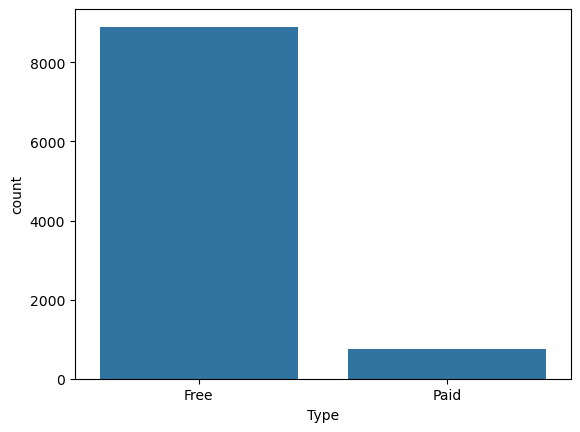

In [61]:
sns.countplot(x= df_copy["Type"])


In [62]:
numerical_features

['index', 'Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated']

<Axes: xlabel='Rating', ylabel='Density'>

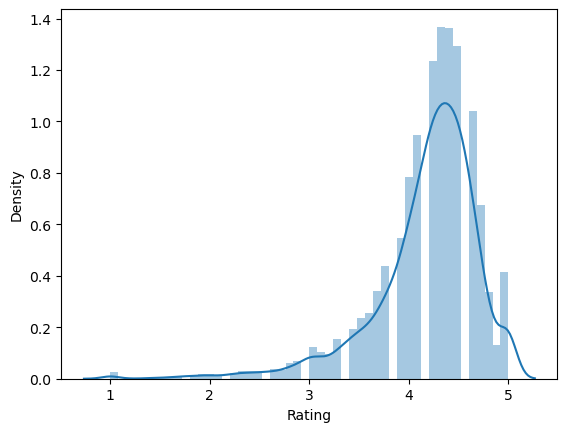

In [63]:
sns.distplot(df_copy["Rating"],kde=True)

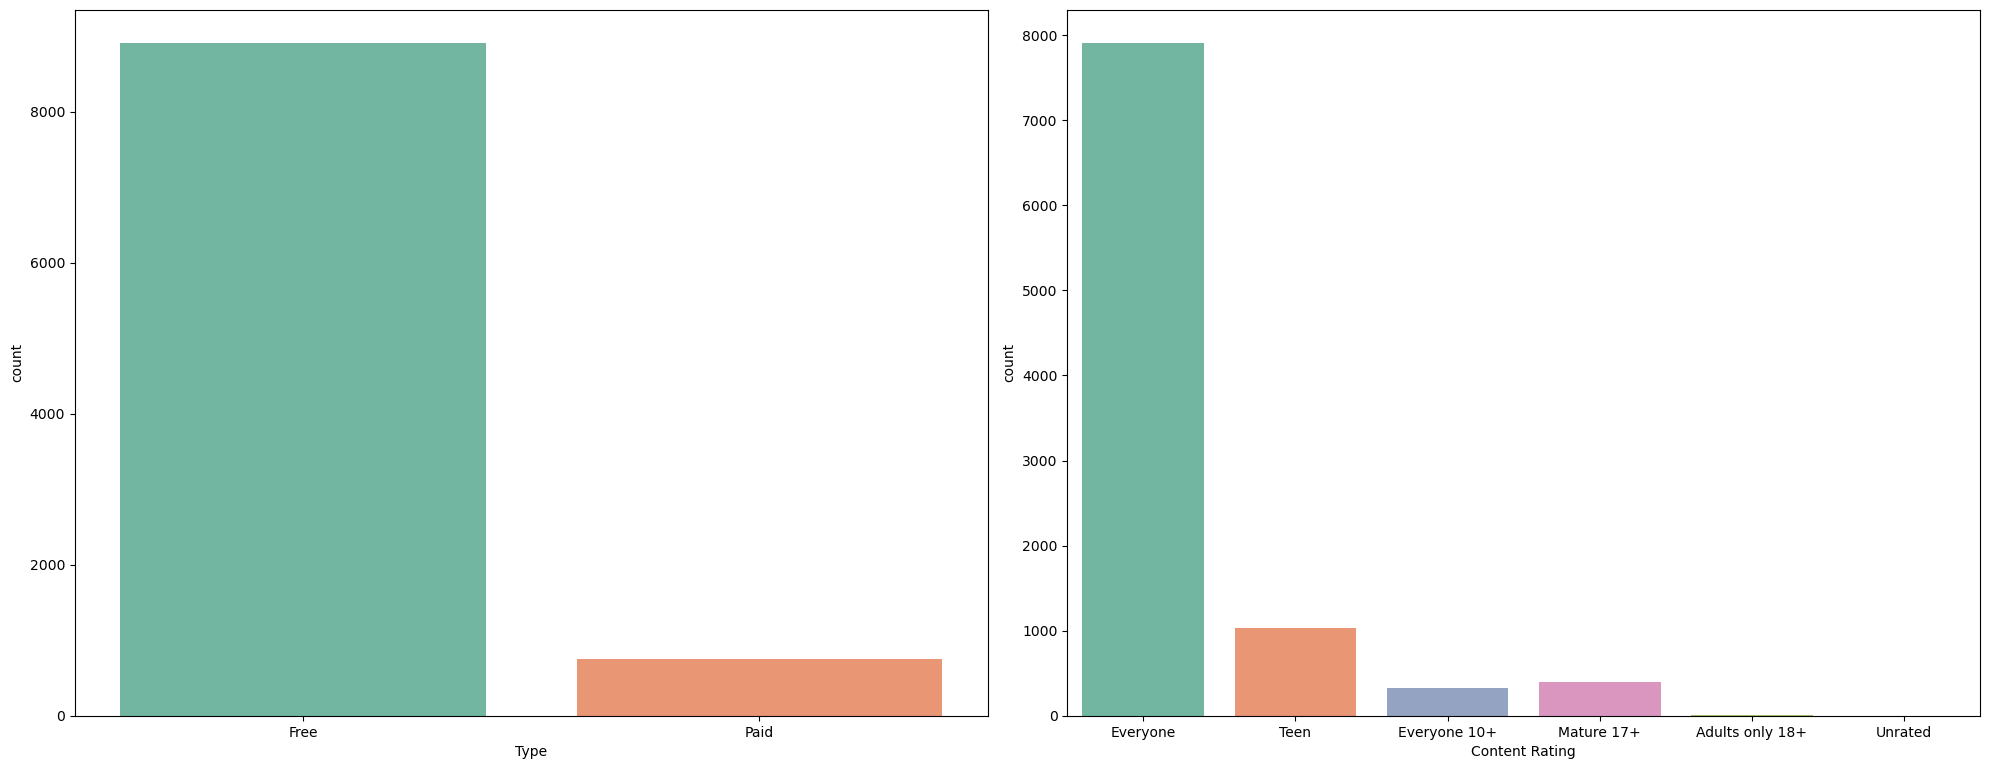

In [64]:
plt.figure(figsize=(20,15))
category = ["Type","Content Rating"]
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.tight_layout()
    

In [65]:
df_copy

,index,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,500000,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,100000,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10353,10836,Sya9a Maroc - FR,FAMILY,4.5,38,54272.0,5000,Free,0,Everyone,Education,2017-07-25,1.48,4.1
10354,10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3686.4,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1
10355,10838,Parkinson Exercices FR,MEDICAL,NaN,3,9728.0,1000,Free,0,Everyone,Medical,2017-01-20,1.0,2.2
10356,10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0,Mature 17+,Books & Reference,2015-01-19,Varies with device,


<Axes: ylabel='count'>

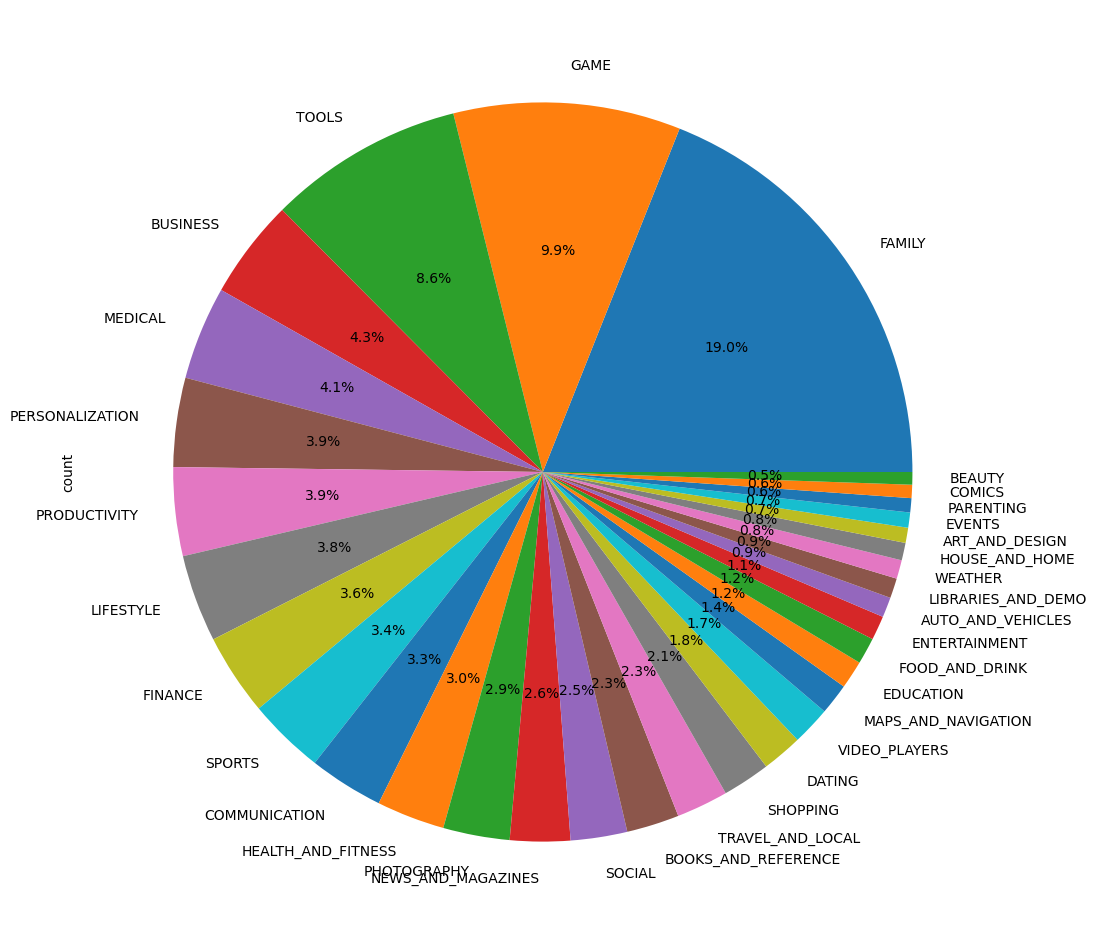

In [72]:
# Q . which is the most popular app
df_copy["Category"].value_counts( ).plot.pie(y=df_copy["Category"],figsize=(12,12),autopct="%1.1f%%")